In [2]:
import numpy as np
import matplotlib.pyplot as plt
import wave
from scipy.io import wavfile as wav
from scipy.signal.windows import hann
from scipy.signal import spectrogram
import librosa

In [3]:
def read_wav_file_data(file_name: str):
    try:
        sample_rate, data = wav.read(file_name)
        print(f"Read file {file_name}")
        print(f"File data total number of sound samples: {len(data)}\nSampling rate: {sample_rate}Hz")
        print(f"Data vector dtype: {data.dtype}")
        return sample_rate, data

    except FileNotFoundError as error:
        print("Caught error:", error)

In [4]:
sample_rate, data = read_wav_file_data("my_ones_low_quality.wav")

Read file my_ones_low_quality.wav
File data total number of sound samples: 144800
Sampling rate: 16000Hz
Data vector dtype: int16


In [5]:
# Normalize and convert to int16
if data.dtype == np.float32 or data.dtype == np.float64:
    max_val = np.iinfo(np.int16).max  # Maximum value for int16
    data_int16 = np.int16(data * max_val)

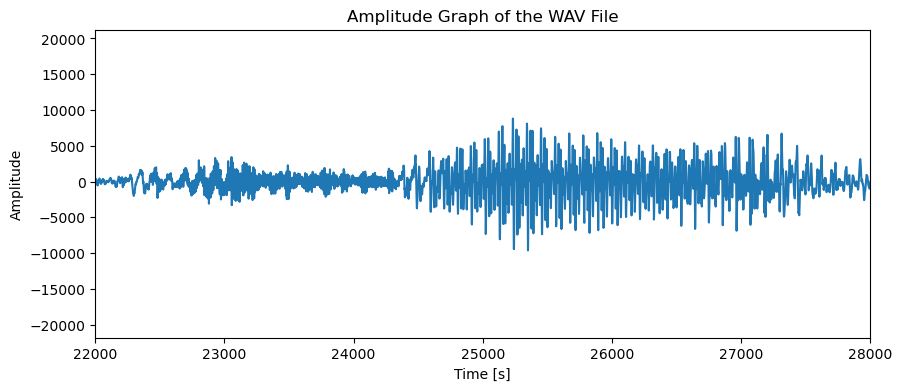

In [26]:
# Generate the time axis
#time = np.linspace(0, len(data) / sample_rate, num=len(data))  # Time array

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(data)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim([22000, 28000])
plt.title('Amplitude Graph of the WAV File')
plt.show()

## Segmentation & Windowing

In [11]:
#Apply normalization
speech_signal_normalized = data / np.max(np.abs(data))

In [13]:
#Defining window length and overlap
window_length_fraction = 0.025
overlap_fraction = 0.015

window_length = int(window_length_fraction * sample_rate) #25ms window length
overlap = int(overlap_fraction * sample_rate) #0ms overlap between windows
step = window_length - overlap #Step size along the entire input signal

In [15]:
# Step 3: Apply the Hanning window
hanning_window = hann(window_length)

In [17]:
reconstructed_signal = np.zeros(len(speech_signal_normalized))
windows = []

In [19]:
for start in range(0, len(speech_signal_normalized) - window_length + 1, step):
    segment = speech_signal_normalized[start:start + window_length]
    windowed_segment = segment * hanning_window
    windows.append(windowed_segment)
    reconstructed_signal[start:start + window_length] += windowed_segment

In [21]:
# Normalize the reconstructed signal (optional)
reconstructed_signal /= np.max(np.abs(reconstructed_signal))

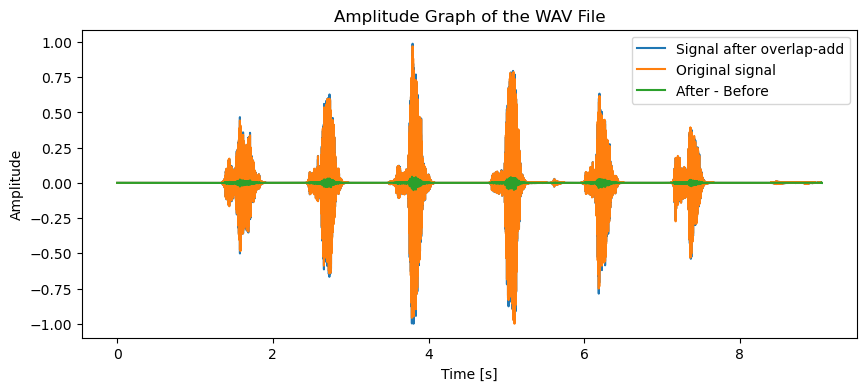

In [22]:
# Generate the time axis
time = np.linspace(0, len(reconstructed_signal) / sample_rate, num=len(reconstructed_signal))  # Time array

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(time, reconstructed_signal, label="Signal after overlap-add")
plt.plot(time, speech_signal_normalized, label="Original signal")
plt.plot(time, reconstructed_signal - speech_signal_normalized, label = "After - Before")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([3.4, 4.4])
plt.title('Amplitude Graph of the WAV File')
plt.legend()
plt.show()

## Covariance & Correlation

In [24]:
print("Number of windows:", len(windows))

Number of windows: 903


In [25]:
#Take a sample window for analysis
sample_window = windows[500] * np.max(data)

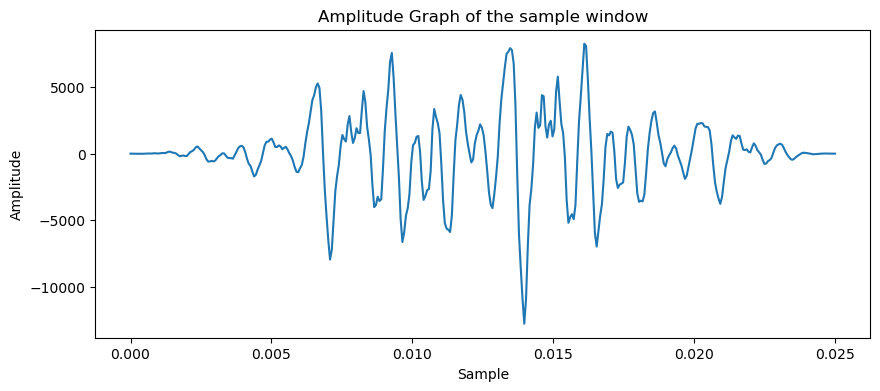

In [32]:
# Plot the waveform

time = np.linspace(0, len(sample_window) / sample_rate, len(sample_window))
plt.figure(figsize=(10, 4))
plt.plot(time, sample_window)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
#plt.xlim([3.4, 4.4])
plt.title('Amplitude Graph of the sample window')
plt.show()

In [18]:
#Remove mean bias
sample_window_zero_mean = sample_window - np.mean(sample_window)

In [19]:
#Auto-covariance calculation
sample_window_size = len(sample_window_zero_mean)
auto_cov = np.correlate(sample_window_zero_mean, sample_window_zero_mean, mode='full') / sample_window_size

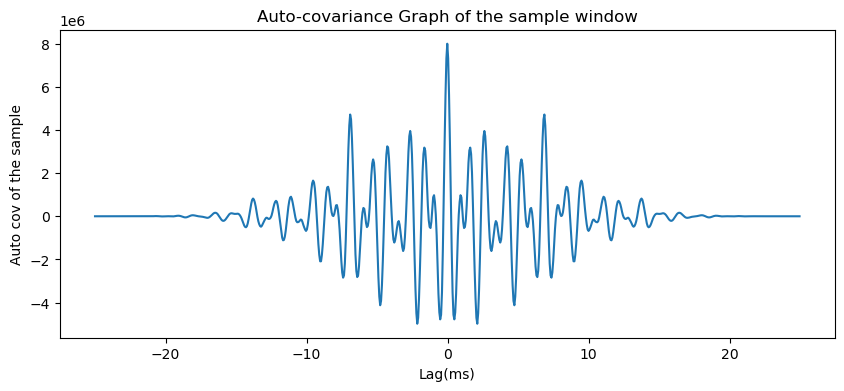

In [20]:
# Plot the Auto-covariance
x_axis = np.linspace((0 - sample_window_size) / sample_rate * 1000, (len(auto_cov) - sample_window_size) / sample_rate * 1000, len(auto_cov))

plt.figure(figsize=(10, 4))
plt.plot(x_axis, auto_cov)
plt.xlabel('Lag(ms)')
plt.ylabel('Auto cov of the sample')
#plt.xlim([3.4, 4.4])
plt.title('Auto-covariance Graph of the sample window')
plt.show()

## Spectogram & Fourier Transforms

In [36]:
#Calculating DFT(Discrete Fourier Transform) of the sample window 
dft = np.fft.fft(data[22000:28000], n=len(data[22000:28000]))

In [42]:
sample_length = len(data[22000:28000])

In [44]:
# Compute the frequency axis for plotting
frequencies = np.fft.fftfreq(sample_length, d=1/sample_rate)[:sample_length//2]
magnitude = np.abs(dft[:sample_length // 2])

In [46]:
frequencies[:10]

array([ 0.        ,  2.66666667,  5.33333333,  8.        , 10.66666667,
       13.33333333, 16.        , 18.66666667, 21.33333333, 24.        ])

In [50]:
magnitude[:10]

array([14966.        , 14603.1311951 , 12993.55074286, 12005.10777493,
       12117.19619743, 13423.88786901, 13386.30577671, 13131.27553993,
       13295.44215604, 12580.34347021])

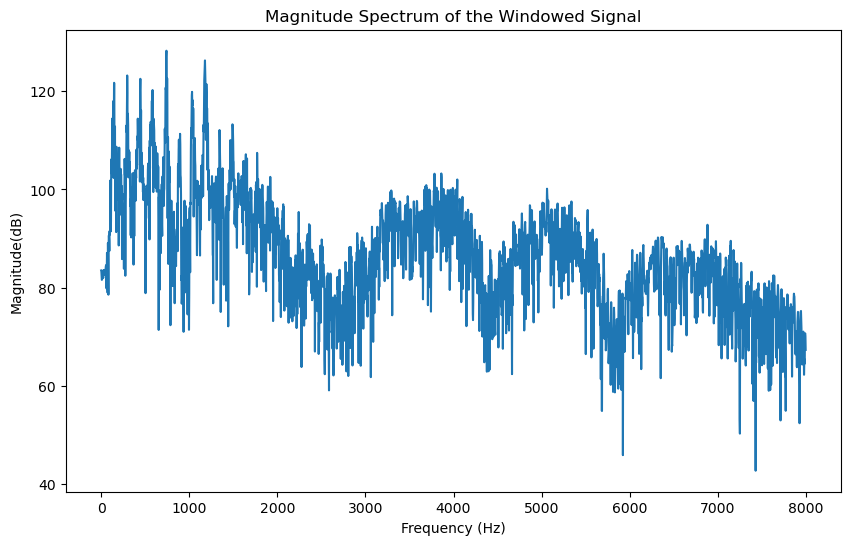

In [52]:
# Plot the magnitude spectrum
plt.figure(figsize=(10, 6))
plt.plot(frequencies, 20 * np.log10(np.abs(magnitude) + np.finfo(float).eps))
plt.title("Magnitude Spectrum of the Windowed Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude(dB)")
plt.show()

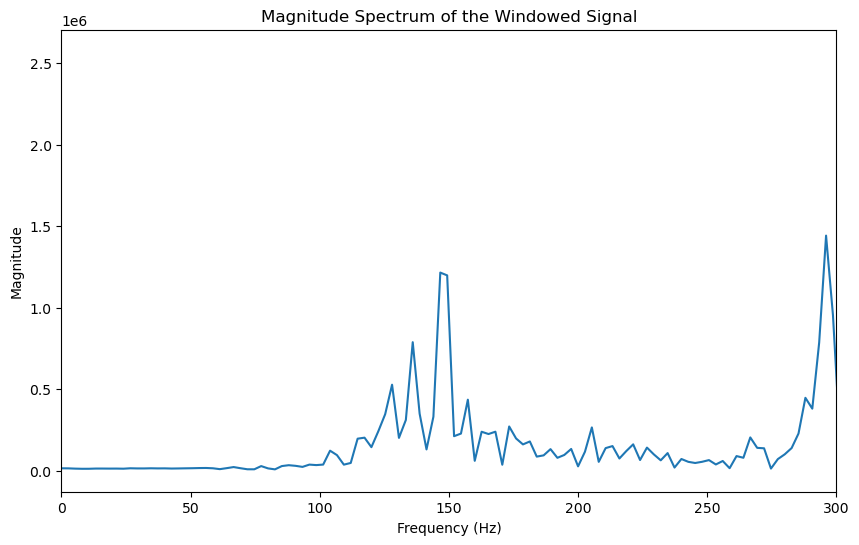

In [56]:
# Plot the magnitude spectrum
plt.figure(figsize=(10, 6))
plt.plot(frequencies, magnitude)
plt.title("Magnitude Spectrum of the Windowed Signal")
plt.xlabel("Frequency (Hz)")
plt.xlim(0, 300)
plt.ylabel("Magnitude")
plt.show()

## Cepstrum & MFCC

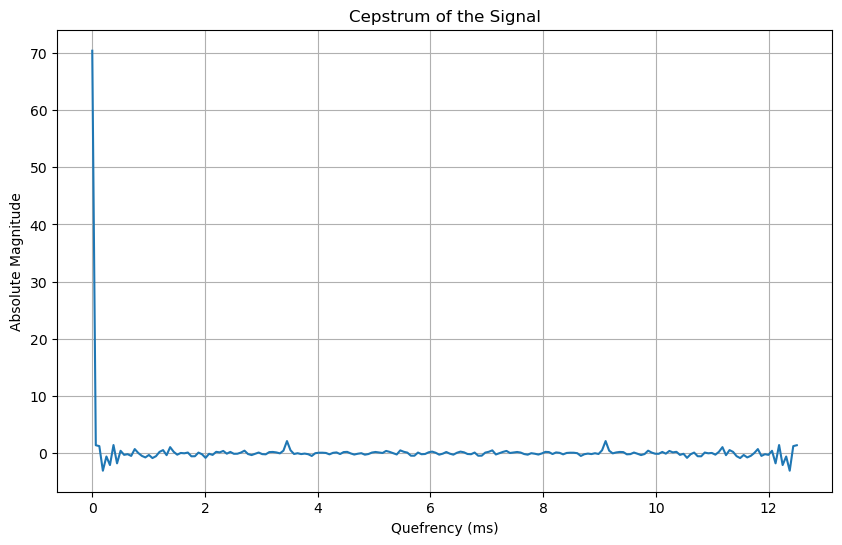

In [29]:
# Plotting the cepstrum
plt.figure(figsize=(10, 6))
x_axis = np.linspace(0, len(magnitude) / sample_rate * 1000, len(magnitude))
plt.plot(x_axis, np.fft.ifft(20 * np.log10(np.abs(magnitude) + np.finfo(float).eps)).real)
plt.title('Cepstrum of the Signal')
plt.xlabel('Quefrency (ms)')
plt.ylabel('Absolute Magnitude')
plt.grid(True)
plt.show()

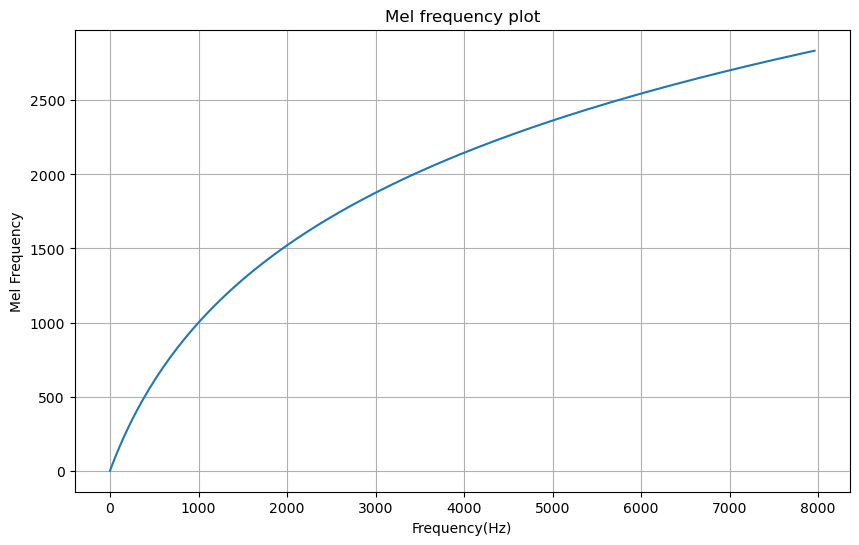

In [30]:
#Plotting Mel-Frequency
# Plotting the cepstrum
plt.figure(figsize=(10, 6))
plt.plot(frequencies, 2595*np.log10(1 + (frequencies / 700)))
plt.title('Mel frequency plot')
plt.xlabel('Frequency(Hz)')
plt.ylabel('Mel Frequency')
plt.grid(True)
plt.show()

In [32]:
# Step 4: Display the MFCCs
plt.figure(figsize=(10, 6))
librosa.display.specshow(librosa.feature.mfcc(y=sample_window, sr=sample_rate, n_mfcc=13), sr=sr, x_axis='time')
plt.colorbar()
plt.title('MFCC')
plt.xlabel('Time')
plt.ylabel('MFCC Coefficients')
plt.show()

OSError: cannot load library 'libsndfile.dll': error 0x7e

<Figure size 1000x600 with 0 Axes>